pip install torch torchvision nltk matplotlib pandas numpy scikit-learn gensim seaborn transformers datasets sentencepiece accelerate ipykernel

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    pipeline,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import torch
from sklearn.manifold import TSNE
from datasets import load_dataset
import evaluate
import numpy as np

# часть 1

In [3]:
np.random.seed(42)

tokens = ["I", "love", "NLP", "!"]

seq_len = len(tokens)
d_k = 8

embeddings = np.random.randn(seq_len, d_k)

W_Q = np.random.randn(d_k, d_k)
W_K = np.random.randn(d_k, d_k)
W_V = np.random.randn(d_k, d_k)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

scores = (Q @ K.T) / np.sqrt(d_k)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)

output = attention_weights @ V

print("Матрица attention weights:")
print(attention_weights)

print("\nВыход attention:")
print(output)


Матрица attention weights:
[[7.67109958e-06 9.68159817e-01 8.54492061e-04 3.09780198e-02]
 [3.55291769e-02 4.69964577e-06 1.99820777e-04 9.64266303e-01]
 [9.95930547e-01 5.24405365e-05 4.01498126e-03 2.03075101e-06]
 [1.28230159e-03 9.37324806e-01 1.55383143e-02 4.58545778e-02]]

Выход attention:
[[-0.68939668 -9.494128   -3.80341092 -5.16705409 -0.79426991  2.65945449
  -0.2745543  -2.76803143]
 [-1.53799964 -3.63883052 -1.78878269 -3.6322275   3.08543646 -3.41871396
   1.81548257 -3.84564413]
 [-0.68259115  8.532587    1.47193389  2.85720415  3.38479494 -2.89007239
  -1.1052181   2.53127537]
 [-0.65523578 -9.31506043 -3.72747038 -5.08239805 -0.78336268  2.60103655
  -0.23924841 -2.78183549]]


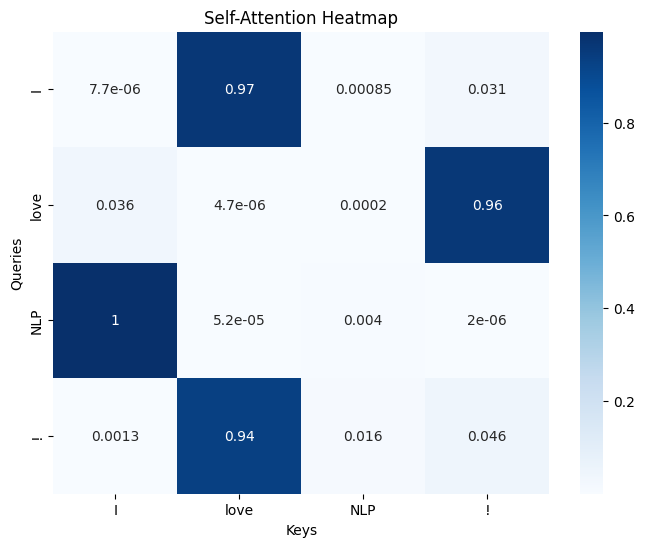

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_weights,
    annot=True,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="Blues"
)

plt.title("Self-Attention Heatmap")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()


### Ответ

Деление на `sqrt(d_k)` нужно для стабилизации значений перед softmax.

Без масштабирования при больших размерностях скалярные произведения становятся слишком большими, softmax начинает выдавать почти one-hot распределения, а градиенты становятся нестабильными.


# часть 2

In [5]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Transformers are changing natural language processing.",
    "ChatGPT is based on large language models.",
    "Tokenization splits words into smaller units.",
    "Unbelievable things happen in neural networks."
]

for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    print(f"Sentence: {sent}")
    print(tokens)
    print("-" * 50)


Sentence: The quick brown fox jumps over the lazy dog.
['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']
--------------------------------------------------
Sentence: Transformers are changing natural language processing.
['transformers', 'are', 'changing', 'natural', 'language', 'processing', '.']
--------------------------------------------------
Sentence: ChatGPT is based on large language models.
['chat', '##gp', '##t', 'is', 'based', 'on', 'large', 'language', 'models', '.']
--------------------------------------------------
Sentence: Tokenization splits words into smaller units.
['token', '##ization', 'splits', 'words', 'into', 'smaller', 'units', '.']
--------------------------------------------------
Sentence: Unbelievable things happen in neural networks.
['unbelievable', 'things', 'happen', 'in', 'neural', 'networks', '.']
--------------------------------------------------


### Почему появляются субтокены?

BPE-токенизация разбивает редкие или неизвестные слова на части.

Это позволяет:
- уменьшить размер словаря;
- обрабатывать новые слова;
- лучше работать с морфологией и редкими формами.


In [6]:
fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased"
)

masked_sentences = [
    "The capital of France is [MASK].",
    "The largest planet is [MASK].",
    "Python is a programming [MASK].",
    "The opposite of hot is [MASK].",
    "Transformers use [MASK] mechanisms."
]

for sent in masked_sentences:
    print(f"\nSentence: {sent}")
    preds = fill_mask(sent, top_k=5)

    for pred in preds:
        print(pred["token_str"], round(pred["score"], 4))


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 1018.87it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Sentence: The capital of France is [MASK].
paris 0.4168
lille 0.0714
lyon 0.0634
marseille 0.0444
tours 0.0303

Sentence: The largest planet is [MASK].
jupiter 0.2848
pluto 0.2079
mars 0.1114
saturn 0.0714
earth 0.0622

Sentence: Python is a programming [MASK].
language 0.9977
languages 0.0011
technique 0.0003
environment 0.0002
style 0.0001

Sentence: The opposite of hot is [MASK].
hot 0.3915
cold 0.3485
cool 0.0229
warm 0.008
heat 0.0079

Sentence: Transformers use [MASK] mechanisms.
two 0.1295
different 0.11
several 0.0881
mechanical 0.0536
multiple 0.0387


In [7]:
generator = pipeline(
    "text-generation",
    model="gpt2"
)

prompts = [
    "Once upon a time",
    "Artificial intelligence will",
    "In the future, humans and robots"
]

for prompt in prompts:
    print("\n========================")
    print("PROMPT:", prompt)

    print("\nGreedy decoding:")
    greedy = generator(
        prompt,
        max_length=50,
        do_sample=False
    )
    print(greedy[0]["generated_text"])

    print("\nTop-k sampling:")
    topk = generator(
        prompt,
        max_length=50,
        do_sample=True,
        top_k=50
    )
    print(topk[0]["generated_text"])

    print("\nTop-p sampling:")
    topp = generator(
        prompt,
        max_length=50,
        do_sample=True,
        top_p=0.9
    )
    print(topp[0]["generated_text"])


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2216.21it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



PROMPT: Once upon a time

Greedy decoding:


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'top_k'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'top_p', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Artificial intelligence will allow us to do things that are impossible to do before.

I'm sure there are many people who say, "I wish I could get a job in AI, but I don't have a job."

I'm sure there are many people who say, "I wish I could get a job in AI, but I don't have a job." They're not even that smart.

In fact, they're pretty smart. We've talked about this before, but it's really hard to explain.

What's happening to AI?

I'm going to use the example of a company that's using AI to help design their products. They're doing a lot of things that are really hard to do before.

You could say, "Hey, we've got to solve the problem that's going to cause all of these problems." And then the question is, how do you solve the problem?

Well, I think there's a huge amount of data out there that we don't yet have. And so you have to start from scratch.

It's a great example.

I think there's a lot of data that we don't yet have. So you have to start from scratch.



PROMPT: In the future,

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In the future, humans and robots will be able to interact with each other, and we will be able to interact with each other in a way that is more natural and human-like.

The future of robotics is going to be a lot more complex than we thought. We're going to have to figure out how to make robots that are more human-like, and how to make robots that are more human-like.

I think that's going to be a big challenge. I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be a big challenge.

I think that's going to be

Top-k sampling:

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In the future, humans and robots will be able to travel between different levels of the same city and compete against each other.

"We are looking at a world that has two worlds in there, but one is based on the city and the other is based on the robots," said Andrew Burt, director of robotics at the MIT Sloan School of Management.

The MIT program is led by Professor Peter Kudrow, who led the effort to develop a system for self-driving cars that is able to do tasks that run for a year in the real world.

In addition to the robots, students are also working on how to understand the human brain, and how the machines can work on complex problems.

"It's about understanding the human mind, and understanding the human brain, and understanding the human brain, and understanding the human brain," said Kudrow. "This is not something we are interested in."

The MIT program uses the Internet and smart phones to build an artificial brain in a laboratory. The robots will be a part of a project ca

### Вывод по стратегиям генерации

- Greedy decoding часто даёт повторяющийся и менее разнообразный текст.
- Top-k добавляет разнообразие.
- Top-p обычно даёт наиболее естественный баланс между качеством и случайностью.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2702.65it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


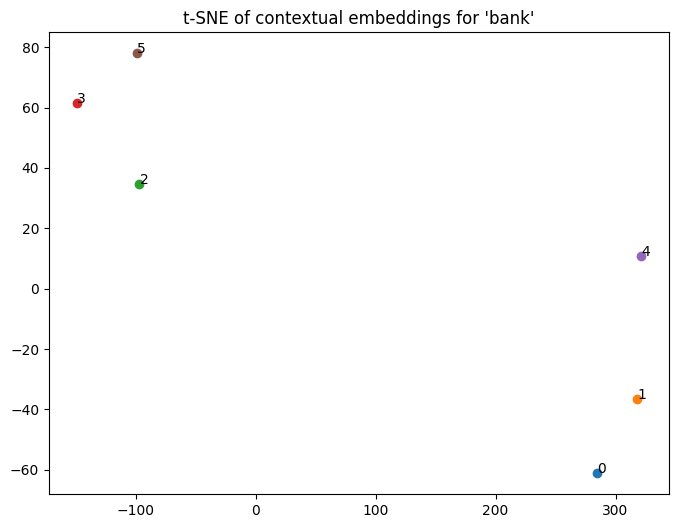

0 I deposited money in the bank.
1 The bank approved my loan.
2 We sat near the river bank.
3 The fisherman stood on the bank.
4 The bank offers good credit cards.
5 Children played near the grassy bank.


In [8]:


model = AutoModel.from_pretrained("bert-base-uncased")

bank_sentences = [
    "I deposited money in the bank.",
    "The bank approved my loan.",
    "We sat near the river bank.",
    "The fisherman stood on the bank.",
    "The bank offers good credit cards.",
    "Children played near the grassy bank."
]

embeddings = []

for sent in bank_sentences:
    inputs = tokenizer(sent, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    idx = tokens.index("bank")
    bank_vector = hidden_states[idx].numpy()

    embeddings.append(bank_vector)

embeddings = np.array(embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=2)
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))

for i, sent in enumerate(bank_sentences):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0] + 0.2, reduced[i, 1], str(i))

plt.title("t-SNE of contextual embeddings for 'bank'")
plt.show()

for i, sent in enumerate(bank_sentences):
    print(i, sent)


# часть 3

In [9]:
dataset = load_dataset("imdb")

dataset

Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /home/arman/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Sun May  3 06:12:00 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [10]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 50000/50000 [00:07<00:00, 7115.41 examples/s] 


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2695.14it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [12]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }


In [14]:
training_args = TrainingArguments(
    output_dir="./results",
    # evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].shuffle(seed=42).select(range(5000)),
    eval_dataset=tokenized_datasets["test"].shuffle(seed=42).select(range(1000)),
    compute_metrics=compute_metrics
)

trainer.train()


Step,Training Loss
100,0.579254
200,0.398712
300,0.375944
400,0.248046
500,0.260710
600,0.243482


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


TrainOutput(global_step=626, training_loss=0.34481465549895557, metrics={'train_runtime': 209.8091, 'train_samples_per_second': 47.662, 'train_steps_per_second': 2.984, 'total_flos': 657777638400000.0, 'train_loss': 0.34481465549895557, 'epoch': 2.0})

In [15]:
results = trainer.evaluate()

print(results)


Training Loss,Validation Loss,Step,Accuracy,F1
0.243482,0.359616,626,0.853000,0.855172


{'eval_loss': 0.35961633920669556, 'eval_accuracy': 0.853, 'eval_f1': 0.8551724137931035}


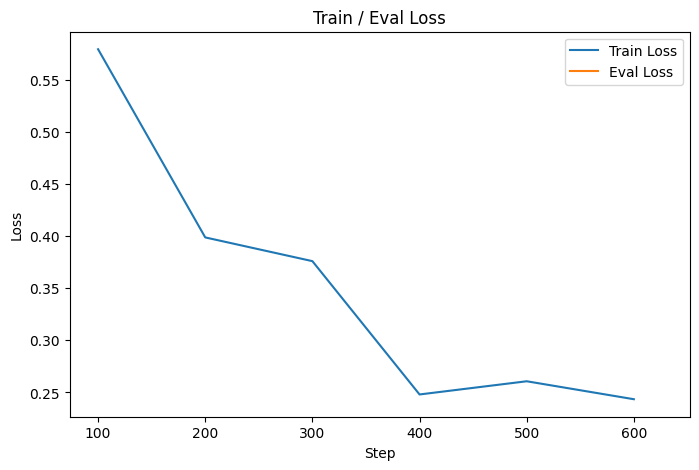

In [16]:
history = trainer.state.log_history

train_loss = []
eval_loss = []
steps_train = []
steps_eval = []

for item in history:
    if "loss" in item:
        train_loss.append(item["loss"])
        steps_train.append(item["step"])

    if "eval_loss" in item:
        eval_loss.append(item["eval_loss"])
        steps_eval.append(item["step"])

plt.figure(figsize=(8, 5))
plt.plot(steps_train, train_loss, label="Train Loss")
plt.plot(steps_eval, eval_loss, label="Eval Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train / Eval Loss")
plt.legend()
plt.show()


## Итоговая таблица

| Метод | Test Accuracy |
|---|---|
| Логистическая регрессия (TF-IDF) | |
| Нейросеть + GloVe | |
| Fine-tuned BERT | 0.853 |
